# Automated Computation of Distal Femoral Osteotomy Correction Angles

This project aims to automate the detection of key anatomical landmarks (such as the hip center, distal femur, and ankle center) in long-leg radiographs (X-rays). By accurately locating these components using a YOLO architecture, we can automatically calculate the mechanical axis and the necessary surgical correction angles for a Distal Femoral Osteotomy (DFO).

## Imports

Import standard data handling, computer vision, and deep learning libraries essential for PyTorch and YOLO operations.

In [1]:
import os
import json
import random
import math
import sys
import torch
import yaml
import numpy as np
import pandas as pd
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

# Ensure CKD (Conformer Keypoint Detection) path is accessible
sys.path.append(os.path.abspath("CKD"))

from models import Conformer_tiny_patch16_keypoint
from utils import extract_coordinates

/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/tf/notebooks/CKD/vision_transformer.py:383: UserWarning: Overwriting vit_base_patch16_224 in registry with vision_transformer.vit_base_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/tf/notebooks/CKD/vision_transformer.py:393: UserWarning: Overwriting vit_base_patch32_224 in registry with vision_transformer.vit_base_patch32_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/tf/notebooks/CKD/vision_transformer.py:402: UserWarning: Overwriting vit_base_patch16_384 in registry with vision_transformer.vit_base_patch16_384. This is b

## GPU Availability Check

Validating hardware acceleration ensures efficiently trained computer vision models. Here we check the PyTorch version and query the presence and name of any available GPUs.

In [2]:
print(f"PyTorch version: {torch.__version__}")
gpu_available = torch.cuda.is_available()
print(f"GPU available: {gpu_available}")

if gpu_available:
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu130
GPU available: True
GPU Device Name: NVIDIA GeForce RTX 4070 Laptop GPU


## Part 1: Data Preparation & Exploratory Data Analysis

Before training our YOLO model, we parse the MS COCO JSON ground truth file to structure the X-ray image data and its YOLO-format label files. We dynamically locate these files, shuffle them to prevent any ordering bias, split them into training, validation, and testing sets, and build the configuration YAML.

### Configuration

Here we define the core paths, target anatomical landmark classes, the desired split ratios across train/val/test, and other global training hyperparameters.

## Reproducibility & Global Configuration

We define all paths, dataset split settings, and training hyperparameters in a single location to ensure consistency across the pipeline. We also establish a global random seed for fully reproducible experiments.

In [3]:
# ==============================================================================
# Global Configuration & Hyperparameters
# ==============================================================================

# Paths
DATA_DIR = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "_annotations_keypoints.coco.json")
OUTPUT_DIR = "yolo_data"

# Dataset Splits & Reproducibility
CLASSES = ["hip", "distal_femur", "ankle"]
SPLIT_RATIOS = (0.8, 0.1, 0.1)  # 80% Train, 10% Validation, 10% Test
SEED = 42

# Hardware Acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loss Function & Metrics
criterion = torch.nn.MSELoss()

# YOLO Object Detection Hyperparameters
OD_EPOCHS = 100
IMGSZ = 640
BATCH_SIZE = 16

# Conformer Keypoint Detection Hyperparameters
KP_EPOCHS = 10
KP_BATCH_SIZE = 8
KP_LEARNING_RATE = 1e-4
TARGET_SIZE = 224
HEATMAP_SCALE = 0.25
SIGMA = 2.0

# Visualization Styling
LANDMARK_COLORS = {
    "fem_head_c": "darkgreen",
    "knee_joint_c": "orange",
    "fujisawa": "red",
    "hinge": "blue",
    "start_point": "purple",
    "ankle_c": "cyan",
    "target_at_ankle": "red"
}

ROI_COLORS = {
    "hip": "green",
    "distal_femur": "blue",
    "ankle": "cyan"
}

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Ensure directories exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Dynamic Dataset Splitting & COCO to YOLO Conversion

We load the MS COCO JSON file containing object annotations (bounding boxes), normalize the coordinates into YOLO format (`x_center, y_center, width, height`), perform a randomized shuffle, and generate the required train/val/test text files which are then indexed in the `data.yaml`.

In [4]:
def prepare_dataset(data_dir, coco_json_path, output_dir="yolo_data"):
    """Converts MS COCO JSON annotations to YOLO format, shuffles images, and creates train/val/test splits."""
    os.makedirs(output_dir, exist_ok=True)
    
    # Re-apply seeds right before shuffling to be doubly sure
    random.seed(SEED)
    
    if not os.path.exists(coco_json_path) or not os.path.exists(data_dir):
        print("Warning: Data directory or COCO JSON does not exist. Generating dummy data for dry run...")
        # Create a dummy COCO JSON structure in memory
        dummy_coco = {
            "images": [{"id": i, "file_name": f"sample_{i}.jpg", "width": 1000, "height": 1000} for i in range(100)],
            "annotations": [{"image_id": i, "category_id": random.randint(1, 3), "bbox": [200, 300, 100, 150], "id": i} for i in range(100)],
            "categories": [{"id": 1, "name": "hip"}, {"id": 2, "name": "distal_femur"}, {"id": 3, "name": "ankle"}]
        }
        coco_data = dummy_coco
    else:
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
    # Create category mapping
    cat_id_to_name = {cat["id"]: cat["name"] for cat in coco_data.get("categories", [])}
    name_to_yolo_id = {name: idx for idx, name in enumerate(CLASSES)}
    
    # Map image IDs to their info and annotations
    images_info = {img["id"]: img for img in coco_data.get("images", [])}
    annotations_by_img = {img_id: [] for img_id in images_info}
    
    for ann in coco_data.get("annotations", []):
        img_id = ann.get("image_id")
        if img_id in annotations_by_img:
            annotations_by_img[img_id].append(ann)
            
    valid_images = list(images_info.keys())
    if not valid_images:
        raise ValueError("No images found in the COCO JSON file.")
        
    # Randomly shuffle images
    random.shuffle(valid_images)
    
    # Calculate split boundaries
    num_imgs = len(valid_images)
    train_end = int(num_imgs * SPLIT_RATIOS[0])
    val_end = train_end + int(num_imgs * SPLIT_RATIOS[1])
    
    splits = {
        "train": valid_images[:train_end],
        "val": valid_images[train_end:val_end],
        "test": valid_images[val_end:]
    }
    
    split_files = {}
    for split_name, img_ids in splits.items():
        images_split_dir = os.path.join(output_dir, "images", split_name)
        labels_split_dir = os.path.join(output_dir, "labels", split_name)
        os.makedirs(images_split_dir, exist_ok=True)
        os.makedirs(labels_split_dir, exist_ok=True)
        
        split_img_paths = []
        for img_id in img_ids:
            img_info = images_info[img_id]
            img_filename = img_info["file_name"]
            src_path = os.path.join(data_dir, img_filename)
            dst_img_path = os.path.join(images_split_dir, os.path.basename(img_filename))
            
            # Either symlink/copy the image or create a dummy file if dry run
            if os.path.exists(src_path):
                if not os.path.exists(dst_img_path):
                    os.symlink(src_path, dst_img_path)
            else:
                # Create dummy file for dry run
                open(dst_img_path, "w").close()
                
            # Convert annotations and write YOLO txt file
            # COCO bbox: [x_min, y_min, width, height]
            txt_filename = os.path.splitext(os.path.basename(img_filename))[0] + ".txt"
            txt_path = os.path.join(labels_split_dir, txt_filename)
            
            with open(txt_path, "w") as f:
                img_w = img_info.get("width", 1000)
                img_h = img_info.get("height", 1000)
                for ann in annotations_by_img[img_id]:
                    bbox = ann.get("bbox", [0, 0, 0, 0])
                    cat_id = ann.get("category_id")
                    cat_name = cat_id_to_name.get(cat_id)
                    if cat_name in name_to_yolo_id:
                        yolo_idx = name_to_yolo_id[cat_name]
                        # Convert to normalized center format
                        x_center = (bbox[0] + bbox[2] / 2.0) / img_w
                        y_center = (bbox[1] + bbox[3] / 2.0) / img_h
                        width = bbox[2] / img_w
                        height = bbox[3] / img_h
                        f.write(f"{yolo_idx} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
            
            split_img_paths.append(os.path.abspath(dst_img_path))
            
        file_path = os.path.abspath(os.path.join(output_dir, f"{split_name}.txt"))
        with open(file_path, "w") as f:
            f.write("\n".join(split_img_paths))
        split_files[split_name] = file_path
        
    # Write the data.yaml for YOLO use
    yaml_data = {
        "train": split_files["train"],
        "val": split_files["val"],
        "test": split_files["test"],
        "nc": len(CLASSES),
        "names": CLASSES
    }
    
    yaml_path = os.path.abspath(os.path.join(output_dir, "data.yaml"))
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_data, f, default_flow_style=False)
        
    return yaml_path

data_yaml_path = prepare_dataset(DATA_DIR, COCO_JSON_PATH, output_dir=OUTPUT_DIR)
print(f"Dataset configuration written to: {data_yaml_path}")

Dataset configuration written to: /tf/notebooks/yolo_data/data.yaml


### Sanity Check Visualization

Before running our expensive training process, we load and visualize 3-5 randomly chosen images and overlay their associated bounding boxes and labels. This confirms the spatial alignment of annotations.

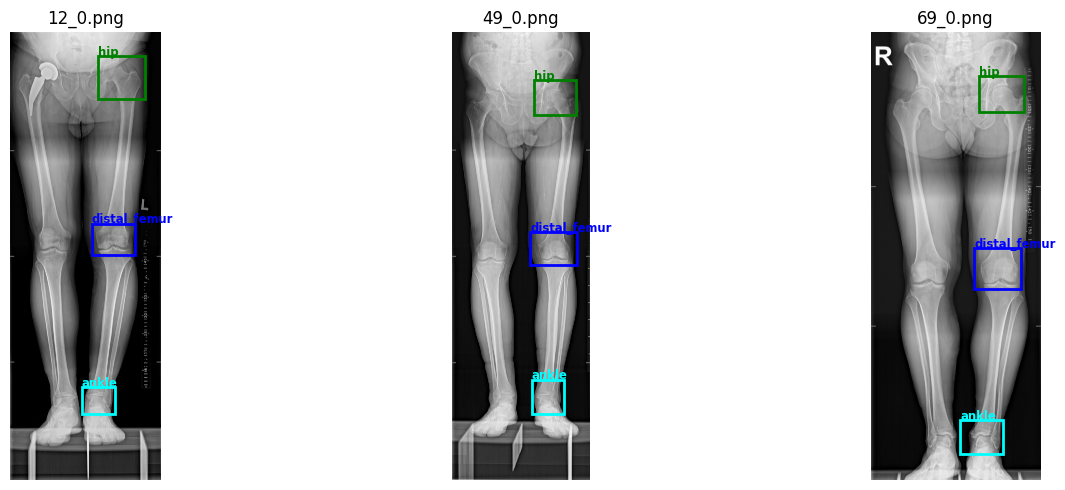

In [5]:
def show_random_samples(data_yaml, num_samples=3):
    with open(data_yaml, "r") as f:
        config = yaml.safe_load(f)
    
    with open(config["train"], "r") as f:
        images = f.read().splitlines()
        
    if not images:
        print("No images found to visualize.")
        return
        
    selected = random.sample(images, min(num_samples, len(images)))
    
    fig, axes = plt.subplots(1, len(selected), figsize=(15, 5))
    if len(selected) == 1:
        axes = [axes]
        
    for idx, img_path in enumerate(selected):
        ax = axes[idx]
        try:
            img = Image.open(img_path)
            ax.imshow(img, cmap="gray")
            w, h = img.size
            
            # Look for matching label file
            label_file = img_path.replace(os.path.join("images", ""), os.path.join("labels", "")).rsplit(".", 1)[0] + ".txt"
            if os.path.exists(label_file):
                with open(label_file, "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            cls_id = int(parts[0])
                            x_center, y_center, box_w, box_h = map(float, parts[1:5])
                            xmin = (x_center - box_w / 2) * w
                            ymin = (y_center - box_h / 2) * h
                            rect_w = box_w * w
                            rect_h = box_h * h
                            
                            label = config["names"][cls_id] if cls_id < len(config["names"]) else str(cls_id)
                            c = ROI_COLORS.get(label, "red")
                            
                            rect = patches.Rectangle((xmin, ymin), rect_w, rect_h, 
                                                     linewidth=2, edgecolor=c, facecolor='none')
                            ax.add_patch(rect)
                            ax.text(xmin, ymin - 5, label, color=c, weight='bold', fontsize='small')
        except Exception as e:
            ax.set_title(f"Error loading {os.path.basename(img_path)}")
            continue
            
        ax.axis("off")
        ax.set_title(os.path.basename(img_path))
        
    plt.tight_layout()
    plt.show()

# Display the sanity check
if os.path.exists(DATA_DIR):
    show_random_samples(data_yaml_path, num_samples=3)
else:
    print("Data directory not found; skipping sanity check visualization in dry run.")

## Core Utilities & Shared Components

To maintain a clean and reliable codebase, we implement shared utilities for image preprocessing, dataset management, and model training. This follows the DRY (Don't Repeat Yourself) principle, ensuring consistency across the Hip, Distal Femur, and Ankle detection stages.

In [6]:
def preprocess_roi(img, bbox, target_size=TARGET_SIZE):
    """
    Crops the Region of Interest (ROI) and applies letterbox resizing 
    to maintain original aspect ratio.
    """
    # bbox: [x_min, y_min, width, height]
    cropped = img.crop((bbox[0], bbox[1], bbox[0] + bbox[2], bbox[1] + bbox[3]))
    
    orig_w, orig_h = cropped.size
    scale = min(target_size / orig_w, target_size / orig_h)
    
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    
    resized = cropped.resize((new_w, new_h), Image.Resampling.LANCZOS)
    
    pad_left = (target_size - new_w) // 2
    pad_top = (target_size - new_h) // 2
    
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    
    return final_img, scale, (pad_left, pad_top)

class RadiographKeypointDataset(Dataset):
    """
    Generic PyTorch Dataset for anatomical keypoint detection in radiographs.
    Handles dynamic keypoint counts and letterbox coordinate adjustments.
    """
    def __init__(self, split_txt_path, coco_json_path, category_name, keypoint_names, target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA):
        super().__init__()
        self.target_size = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma = sigma
        self.keypoint_names = keypoint_names
        self.num_keypoints = len(keypoint_names)
        
        with open(split_txt_path, "r") as f:
            valid_filenames = {os.path.basename(p) for p in f.read().splitlines()}
        
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
        img_info_map = {img["id"]: img for img in coco_data["images"]}
        cat_id = next((cat["id"] for cat in coco_data["categories"] if cat["name"] == category_name), None)
        
        self.samples = []
        for ann in coco_data["annotations"]:
            img_id = ann["image_id"]
            if img_id in img_info_map:
                filename = img_info_map[img_id]["file_name"]
                if filename in valid_filenames and ann["category_id"] == cat_id and ann.get("keypoints"):
                    self.samples.append({
                        "img_path": os.path.join(os.path.dirname(coco_json_path), filename),
                        "bbox": ann["bbox"],  # [x, y, w, h]
                        "keypoints": ann["keypoints"]  # Flat list [x, y, v, x, y, v, ...]
                    })
                        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        sample = self.samples[idx]
        bbox = sample["bbox"]
        
        # Load and Preprocess ROI
        img = Image.open(sample["img_path"]).convert("RGB")
        roi_img, scale, padding = preprocess_roi(img, bbox, self.target_size)
        
        # Adjust Keypoints to padded ROI space
        final_kps = []
        for i in range(self.num_keypoints):
            kp_x = sample["keypoints"][i * 3]
            kp_y = sample["keypoints"][i * 3 + 1]
            
            # Sub-crop relative adjustment
            rel_x, rel_y = kp_x - bbox[0], kp_y - bbox[1]
            
            # Map into letterbox space
            final_x = rel_x * scale + padding[0]
            final_y = rel_y * scale + padding[1]
            final_kps.append([final_x, final_y])
        
        img_tensor = torch.from_numpy(np.array(roi_img)).permute(2, 0, 1).float() / 255.0
        
        # Generate Heatmaps
        hm_size = int(self.target_size * self.heatmap_scale)
        heatmap = np.zeros((self.num_keypoints, hm_size, hm_size), dtype=np.float32)
        x_grid = np.arange(0, hm_size, 1, np.float32)
        y_grid = np.arange(0, hm_size, 1, np.float32)[:, np.newaxis]
        
        for i in range(self.num_keypoints):
            kp_hm_x = final_kps[i][0] * self.heatmap_scale
            kp_hm_y = final_kps[i][1] * self.heatmap_scale
            heatmap[i] = np.exp(-((x_grid - kp_hm_x)**2 + (y_grid - kp_hm_y)**2) / (2 * self.sigma**2))
        
        return {
            "image": img_tensor,
            "heatmap": torch.from_numpy(heatmap),
            "keypoint": torch.tensor(final_kps, dtype=torch.float32),
            "img_path": sample["img_path"]
        }

def train_keypoint_model(model, train_loader, val_loader, optimizer, criterion, epochs, device, stage_name=""):
    """Generic training routine for Conformer models with loss and NMSE tracking."""
    train_losses, val_losses, val_nmses = [], [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            imgs, targets = batch["image"].to(device), batch["heatmap"].to(device)
            optimizer.zero_grad()
            pred_hms = model(imgs)
            loss = criterion(pred_hms, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        train_loss = epoch_loss / len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss, epoch_preds, epoch_gts = 0.0, [], []
        with torch.no_grad():
            for batch in val_loader:
                imgs, targets, gts = batch["image"].to(device), batch["heatmap"].to(device), batch["keypoint"]
                pred_hms = model(imgs)
                val_loss += criterion(pred_hms, targets).item()
                
                # Extract coordinates [Batch, K, 2]
                coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
                epoch_preds.append(coords)
                epoch_gts.append(gts)
                
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # Calculate NMSE
        preds_cat = torch.cat(epoch_preds, dim=0)
        gts_cat = torch.cat(epoch_gts, dim=0)
        diff = preds_cat - gts_cat
        mse = torch.mean(torch.sum(diff ** 2, dim=-1))
        nmse = (mse / (TARGET_SIZE ** 2)).item()
        val_nmses.append(nmse)
        
        print(f"Epoch {epoch+1}/{epochs} ({stage_name}) | Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | NMSE: {nmse:.6f}")
        
    return train_losses, val_losses, val_nmses

def visualize_keypoint_evaluation(sample_batch, stage_name, keypoint_names):
    """Side-by-side plot of prediction overlay and predicted heatmap."""
    sample_img, sample_hms, sample_gt, sample_pred = sample_batch
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Overlay Plot
    img_show = sample_img[0].permute(1, 2, 0).numpy()
    ax1.imshow(img_show, cmap="gray")
    
    for i, name in enumerate(keypoint_names):
        c = LANDMARK_COLORS.get(name, "red")
        ax1.plot(sample_gt[0, i, 0], sample_gt[0, i, 1], 'o', color=c, markersize=8, label=f"GT {name}")
        ax1.plot(sample_pred[0, i, 0], sample_pred[0, i, 1], 'x', color=c, markersize=8, label=f"Pred {name}")
        
    ax1.legend(fontsize='x-small', loc='upper right')
    ax1.set_title(f"{stage_name} Prediction Overlay")
    ax1.axis("off")
    
    # Heatmap Plot (Max across channels)
    hm_show = torch.max(sample_hms[0], dim=0)[0].numpy()
    im = ax2.imshow(hm_show, cmap='hot', interpolation='nearest')
    ax2.set_title(f"Predicted Heatmap ({stage_name})")
    ax2.axis("off")
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

## Part 2: Regions of Interests Detection

### Model Initialization & Training

We instantiate the YOLO architecture and conduct the optimization process over our processed anatomical dataset.

#### Load Model

We load the lightweight pretrained YOLO26 architecture to warm-start our feature extractors.

In [7]:
print("Loading YOLO26 pretrained weights...")
model = YOLO("yolo26n.pt")

Loading YOLO26 pretrained weights...


#### Training Loop

Execute the primary training routine using our configuration YAML and predefined hyperparameters. YOLO handles optimization, checkpointing, and metric validation internally.

In [8]:
print("Starting YOLO training loop...")
results = model.train(
    data=data_yaml_path,
    epochs=OD_EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    device=0,
    
    # Customizing augmentations for Medical Radiographs
    fliplr=0.5,    # Allow horizontal flips (left/right leg symmetry)
    flipud=0.0,    # Prevent upside-down hips/ankles
    degrees=5.0,   # Limit rotation to gentle patient tilts
    scale=0.1,     # Minor zoom-in/out scaling
    mosaic=1.0     # Keep mosaic active for small features
)
print("Training complete!")

Starting YOLO training loop...
New https://pypi.org/project/ultralytics/8.4.45 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tf/notebooks/yolo_data/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo2

#### Training Progress

Visualize the resulting optimization progression by plotting both training and validation loss alongside the mean Average Precision (mAP) scores over time.

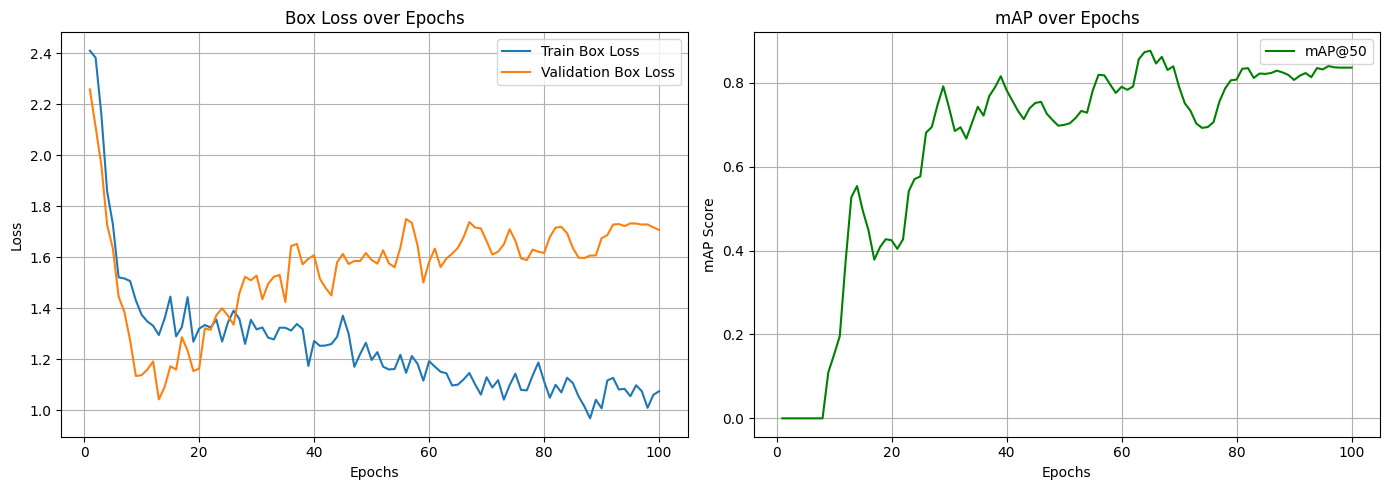

In [9]:
# Ultralytics typically outputs runs/detect/train/results.csv
results_path = os.path.join("runs", "detect", "train", "results.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Training and Validation Loss
    if "train/box_loss" in df.columns and "val/box_loss" in df.columns:
        ax1.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        ax1.plot(df["epoch"], df["val/box_loss"], label="Validation Box Loss")
        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Loss")
        ax1.set_title("Box Loss over Epochs")
        ax1.legend()
        ax1.grid(True)
        
    # Plot mAP over time
    map_col = [col for col in df.columns if "mAP50" in col]
    if map_col:
        ax2.plot(df["epoch"], df[map_col[0]], label="mAP@50", color="green")
        ax2.set_xlabel("Epochs")
        ax2.set_ylabel("mAP Score")
        ax2.set_title("mAP over Epochs")
        ax2.legend()
        ax2.grid(True)
        
    plt.tight_layout()
    plt.show()
else:
    print("Results CSV not found; check YOLO output run path. (Expected during dry runs or before training completes)")

### Evaluation & Inference

After training concludes, it is critical to evaluate our model's boundary box positioning and anatomical landmark identification on previously unseen test data.

#### Test Set Inference

Run validation metrics strictly over the held-out test split to ensure the model generalizes cleanly to new patient X-rays.

In [10]:
print("Running model validation on the test split...")
test_metrics = model.val(data=data_yaml_path, split="test")
print(f"Test Set mAP50: {test_metrics.box.map50:.4f}")
print(f"Test Set mAP50-95: {test_metrics.box.map:.4f}")

Running model validation on the test split...
Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 4.1±1.0 ms, read: 170.7±13.5 MB/s, size: 8515.3 KB)
val: Scanning /tf/notebooks/yolo_data/labels/test.cache... 7 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7/7 2.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9s/it 2.9s
                   all          7         21      0.722      0.711      0.758      0.458
                   hip          7          7      0.711      0.704      0.665      0.423
          distal_femur          7          7       0.61      0.571      0.751      0.494
                 ankle          7          7      0.845      0.857       0.86      0.458
Speed: 1.0ms preprocess, 27.4ms inference, 0.0ms loss, 0.5ms postpr

#### Testing Metrics

Display standard PR curves, F1-score curves, and confusion matrix heatmaps generated during the testing stage.

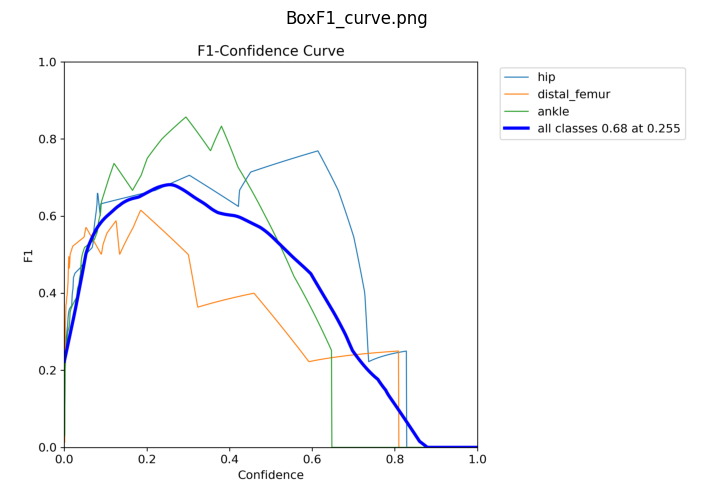

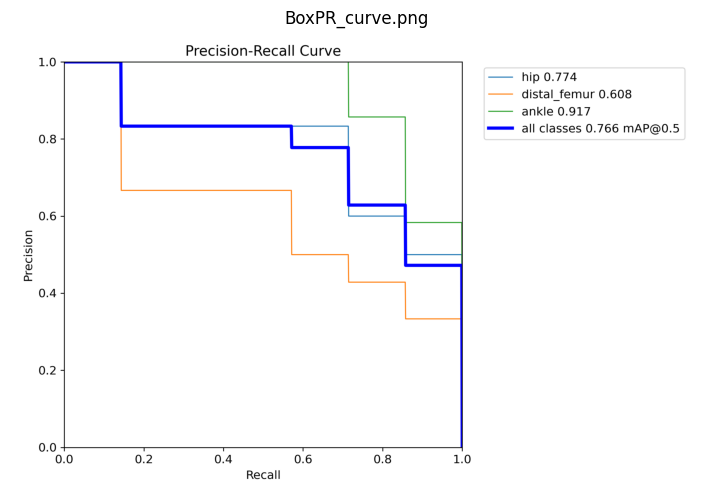

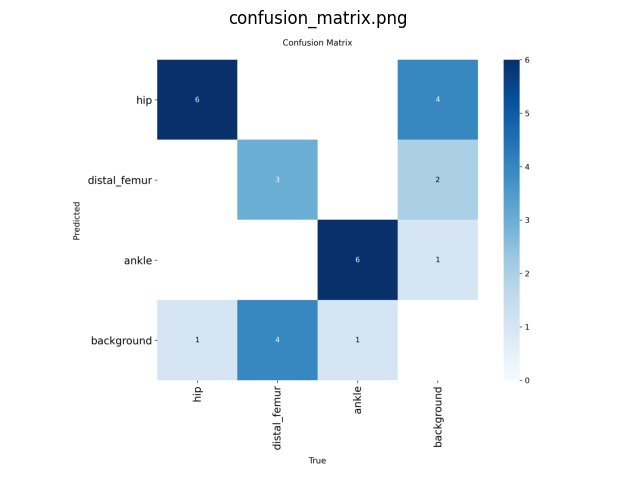

In [11]:
val_dir = os.path.join("runs", "detect", "val")
metric_plots = ["BoxF1_curve.png", "BoxPR_curve.png", "confusion_matrix.png"]

for plot_name in metric_plots:
    plot_path = os.path.join(val_dir, plot_name)
    if os.path.exists(plot_path):
        plt.figure(figsize=(10, 6))
        img = Image.open(plot_path)
        plt.imshow(img)
        plt.axis("off")
        plt.title(plot_name)
        plt.show()
    else:
        print(f"{plot_name} not found in {val_dir} (Available after evaluation)")

#### Result Inspection

Load and visualize raw prediction overlays alongside ground truth boxes on the test dataset so clinicians or engineers can spot correctable alignment errors or edge cases.

Running inference on test sample: /tf/notebooks/yolo_data/images/test/27_0.png

image 1/1 /tf/notebooks/yolo_data/images/test/27_0.png: 640x256 2 hips, 1 distal_femur, 73.9ms
Speed: 3.3ms preprocess, 73.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 256)


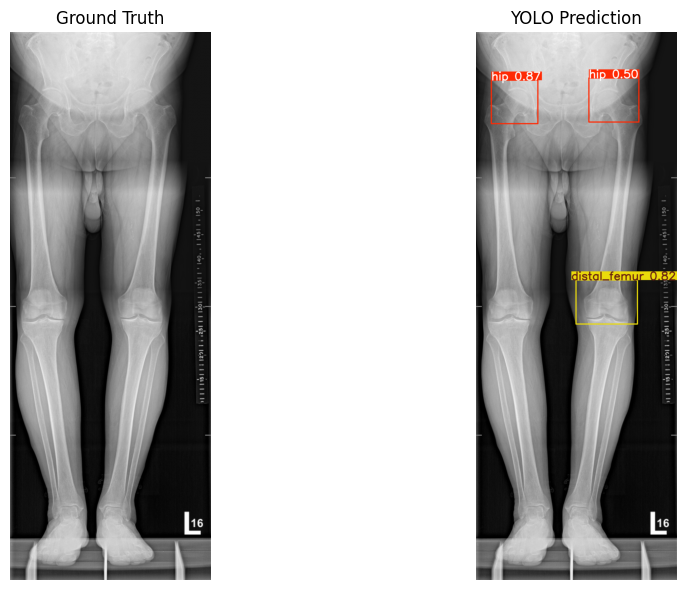

In [12]:
# Read test image paths
with open(os.path.join("yolo_data", "test.txt"), "r") as f:
    test_images = f.read().splitlines()

if test_images:
    sample_img = random.choice(test_images)
    print(f"Running inference on test sample: {sample_img}")
    
    # Run model prediction
    pred = model(sample_img)
    
    # Display results side-by-side
    fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Ground truth display
    img_pil = Image.open(sample_img)
    ax_gt.imshow(img_pil, cmap="gray")
    ax_gt.set_title("Ground Truth")
    ax_gt.axis("off")
    
    # Predicted rendering using ultralytics native plotting
    res_plotted = pred[0].plot()
    ax_pred.imshow(res_plotted)
    ax_pred.set_title("YOLO Prediction")
    ax_pred.axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("No test images found.")

## Part 3: Hip Keypoint Detection

In this stage, we crop the detected hip region using letterbox resizing (to preserve original anatomical aspect ratios) and train a Conformer-based keypoint detector to locate the femoral head center (`fem_head_c`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset that reads the train/val/test sets generated during Stage 1 to guarantee data consistency, crops the hip bounding box, applies letterbox padding, and builds 2D Gaussian heatmaps for the keypoint (`fem_head_c`) learning objective.

In [13]:
# Hip Landmarks: center of femoral head
hip_kp_names = ["fem_head_c"]

if os.path.exists(COCO_JSON_PATH):
    # Initialize Generic Dataset using global configs
    train_ds_hip = RadiographKeypointDataset(os.path.join(OUTPUT_DIR, "train.txt"), COCO_JSON_PATH, "hip", hip_kp_names)
    val_ds_hip = RadiographKeypointDataset(os.path.join(OUTPUT_DIR, "val.txt"), COCO_JSON_PATH, "hip", hip_kp_names)
    test_ds_hip = RadiographKeypointDataset(os.path.join(OUTPUT_DIR, "test.txt"), COCO_JSON_PATH, "hip", hip_kp_names)

    if len(train_ds_hip) > 0: train_loader_hip = DataLoader(train_ds_hip, batch_size=KP_BATCH_SIZE, shuffle=True)
    if len(val_ds_hip) > 0: val_loader_hip = DataLoader(val_ds_hip, batch_size=KP_BATCH_SIZE, shuffle=False)
    if len(test_ds_hip) > 0: test_loader_hip = DataLoader(test_ds_hip, batch_size=KP_BATCH_SIZE, shuffle=False)
    
    print(f"Hip Stage Loaded! Samples: {len(train_ds_hip)} train, {len(val_ds_hip)} val, {len(test_ds_hip)} test")
else:
    print("Annotations not found; skipping Hip setup.")

Hip Stage Loaded! Samples: 56 train, 7 val, 7 test


### Model Initialization & Hyperparameters

Instantiate the Conformer architecture wrapper expecting a single keypoint target (`fem_head_c`).

### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps.

Epoch 1/10 (Hip) | Loss: 0.125153 | Val Loss: 0.005392 | NMSE: 0.327690
Epoch 2/10 (Hip) | Loss: 0.046329 | Val Loss: 0.004722 | NMSE: 0.275222
Epoch 3/10 (Hip) | Loss: 0.015977 | Val Loss: 0.005760 | NMSE: 0.327540
Epoch 4/10 (Hip) | Loss: 0.008373 | Val Loss: 0.005766 | NMSE: 0.418580
Epoch 5/10 (Hip) | Loss: 0.006939 | Val Loss: 0.005556 | NMSE: 0.384416
Epoch 6/10 (Hip) | Loss: 0.006061 | Val Loss: 0.005293 | NMSE: 0.218265
Epoch 7/10 (Hip) | Loss: 0.005374 | Val Loss: 0.005004 | NMSE: 0.174225
Epoch 8/10 (Hip) | Loss: 0.005118 | Val Loss: 0.004819 | NMSE: 0.181934
Epoch 9/10 (Hip) | Loss: 0.004933 | Val Loss: 0.004730 | NMSE: 0.233647
Epoch 10/10 (Hip) | Loss: 0.004810 | Val Loss: 0.004688 | NMSE: 0.280707


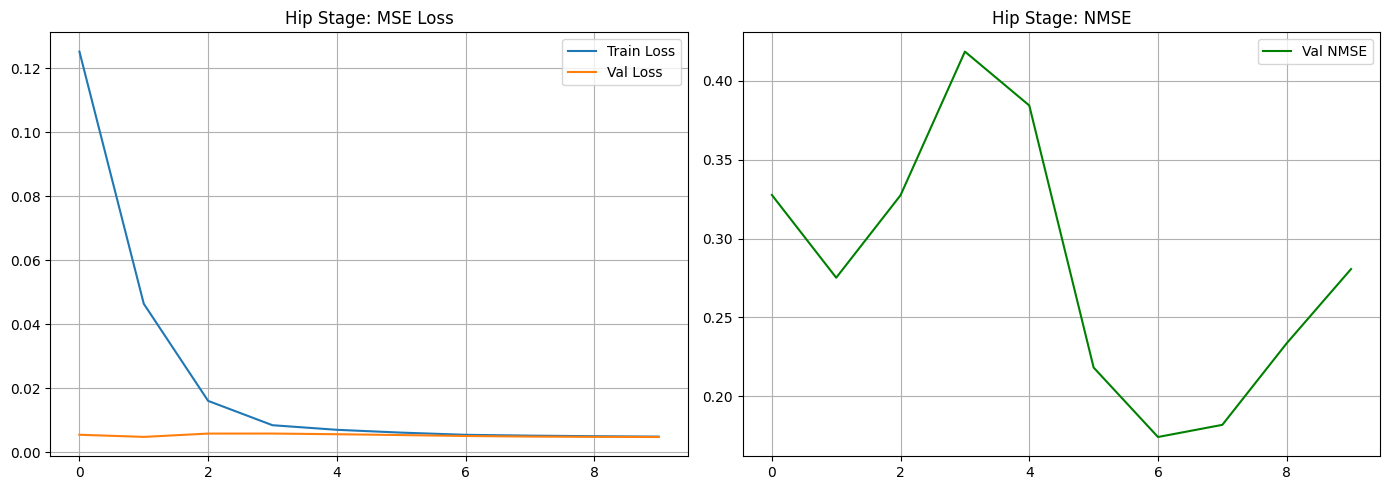

In [14]:
# Instantiate Conformer for Hip
model_hip = Conformer_tiny_patch16_keypoint(num_keypoints=1).to(device)
optimizer_hip = optim.AdamW(model_hip.parameters(), lr=KP_LEARNING_RATE)

if 'train_loader_hip' in locals():
    train_losses, val_losses, val_nmses = train_keypoint_model(
        model_hip, train_loader_hip, val_loader_hip, 
        optimizer_hip, criterion, KP_EPOCHS, device, stage_name="Hip"
    )
    
    # Plot Metrics
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss"), ax1.plot(val_losses, label="Val Loss")
    ax1.set_title("Hip Stage: MSE Loss"), ax1.legend(), ax1.grid(True)
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2.set_title("Hip Stage: NMSE"), ax2.legend(), ax2.grid(True)
    plt.tight_layout(), plt.show()
else:
    print("Skipping Hip training (Dataset missing).")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps using the supplied `extract_coordinates` utility, compute Normalized MSE, and visualize the ground truth against predictions.

Hip Test Set NMSE: 0.212534


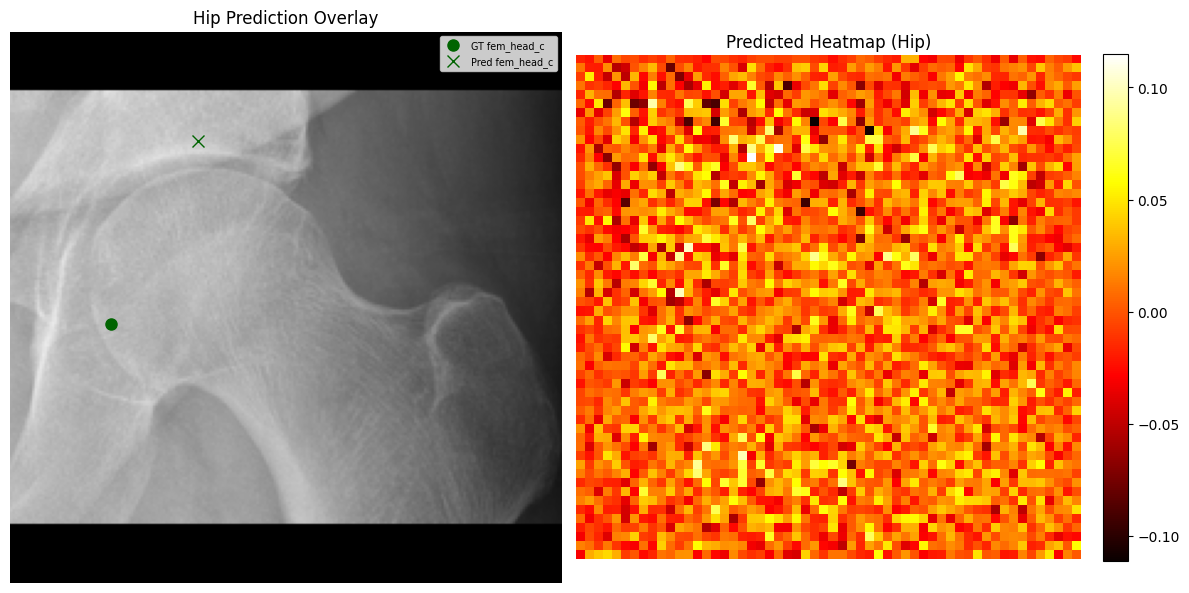

In [15]:
if 'test_loader_hip' in locals():
    model_hip.eval()
    all_preds, all_gts, sample_batch = [], [], None
    
    with torch.no_grad():
        for batch in test_loader_hip:
            imgs, kps = batch["image"].to(device), batch["keypoint"]
            pred_hms = model_hip(imgs)
            coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            all_preds.append(coords), all_gts.append(kps)
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), kps, coords)
                
    nmse_val = (torch.mean(torch.sum((torch.cat(all_preds) - torch.cat(all_gts))**2, dim=-1)) / (TARGET_SIZE**2)).item()
    print(f"Hip Test Set NMSE: {nmse_val:.6f}")
    
    visualize_keypoint_evaluation(sample_batch, "Hip", ["fem_head_c"])
else:
    print("Skipping Hip evaluation.")

## Part 4: Distal Femur Keypoint Detection

In this stage, we crop the detected distal femur region using letterbox resizing (to preserve original anatomical aspect ratios) and train a Conformer-based keypoint detector to locate the distal femur keypoints (`knee_joint_c`, `fujisawa`, `hinge`, `start_point`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset that reads the train/val/test sets generated during Stage 1 to guarantee data consistency, crops the distal femur bounding box, applies letterbox padding, and builds 2D Gaussian heatmaps for the 4 keypoints (`knee_joint_c`, `fujisawa`, `hinge`, `start_point`) learning objective.

In [16]:
# Distal Femur Landmarks: joint center, fujisawa, hinge pivot, start point
df_kp_names = ["knee_joint_c", "fujisawa", "hinge", "start_point"]

if os.path.exists(COCO_JSON_PATH):
    # Initialize Generic Dataset using global configs
    train_ds_df = RadiographKeypointDataset(os.path.join(OUTPUT_DIR, "train.txt"), COCO_JSON_PATH, "distal_femur", df_kp_names)
    val_ds_df = RadiographKeypointDataset(os.path.join(OUTPUT_DIR, "val.txt"), COCO_JSON_PATH, "distal_femur", df_kp_names)
    test_ds_df = RadiographKeypointDataset(os.path.join(OUTPUT_DIR, "test.txt"), COCO_JSON_PATH, "distal_femur", df_kp_names)

    if len(train_ds_df) > 0: train_loader_df = DataLoader(train_ds_df, batch_size=KP_BATCH_SIZE, shuffle=True)
    if len(val_ds_df) > 0: val_loader_df = DataLoader(val_ds_df, batch_size=KP_BATCH_SIZE, shuffle=False)
    if len(test_ds_df) > 0: test_loader_df = DataLoader(test_ds_df, batch_size=KP_BATCH_SIZE, shuffle=False)
    
    print(f"Distal Femur Stage Loaded! Samples: {len(train_ds_df)} train, {len(val_ds_df)} val, {len(test_ds_df)} test")
else:
    print("Annotations not found; skipping Distal Femur setup.")

Distal Femur Stage Loaded! Samples: 55 train, 7 val, 7 test


### Model Initialization & Hyperparameters

Instantiate the Conformer architecture wrapper expecting 4 keypoint targets (`knee_joint_c`, `fujisawa`, `hinge`, `start_point`).

### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps.

Epoch 1/10 (Distal Femur) | Loss: 0.128403 | Val Loss: 0.005990 | NMSE: 0.241924
Epoch 2/10 (Distal Femur) | Loss: 0.055611 | Val Loss: 0.008088 | NMSE: 0.324065
Epoch 3/10 (Distal Femur) | Loss: 0.026242 | Val Loss: 0.009705 | NMSE: 0.376073
Epoch 4/10 (Distal Femur) | Loss: 0.013686 | Val Loss: 0.009385 | NMSE: 0.417877
Epoch 5/10 (Distal Femur) | Loss: 0.008376 | Val Loss: 0.007691 | NMSE: 0.342823
Epoch 6/10 (Distal Femur) | Loss: 0.006201 | Val Loss: 0.006071 | NMSE: 0.318006
Epoch 7/10 (Distal Femur) | Loss: 0.005289 | Val Loss: 0.005134 | NMSE: 0.413996
Epoch 8/10 (Distal Femur) | Loss: 0.004908 | Val Loss: 0.004574 | NMSE: 0.297018
Epoch 9/10 (Distal Femur) | Loss: 0.004723 | Val Loss: 0.004313 | NMSE: 0.299009
Epoch 10/10 (Distal Femur) | Loss: 0.004598 | Val Loss: 0.004241 | NMSE: 0.348964


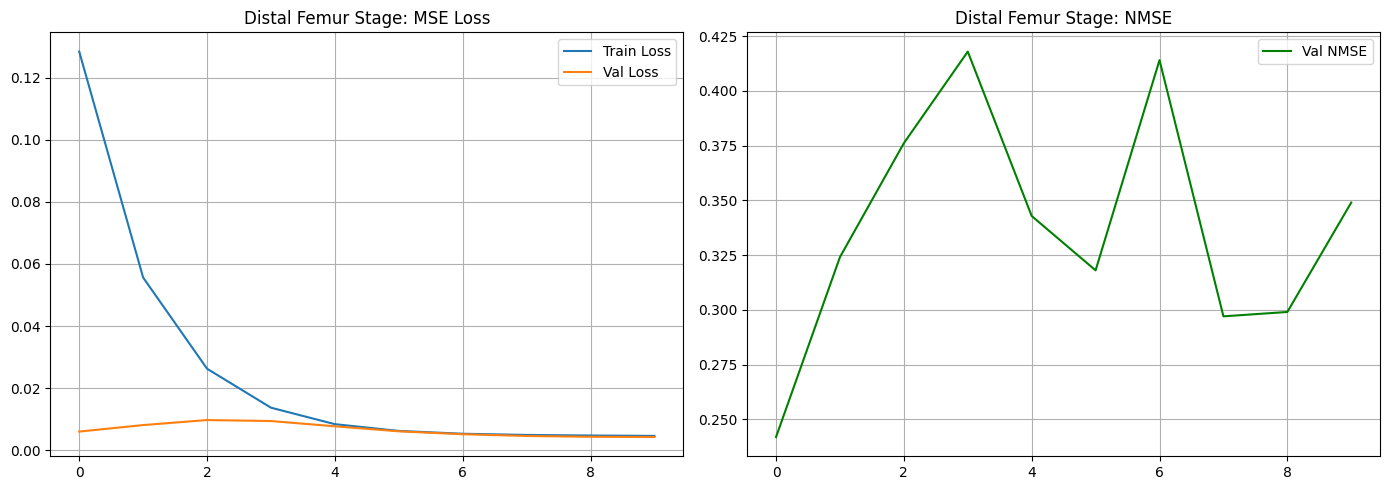

In [17]:
# Instantiate Conformer for Distal Femur (4 keypoints)
model_df = Conformer_tiny_patch16_keypoint(num_keypoints=4).to(device)
optimizer_df = optim.AdamW(model_df.parameters(), lr=KP_LEARNING_RATE)

if 'train_loader_df' in locals():
    train_losses, val_losses, val_nmses = train_keypoint_model(
        model_df, train_loader_df, val_loader_df, 
        optimizer_df, criterion, KP_EPOCHS, device, stage_name="Distal Femur"
    )
    
    # Plot Metrics
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss"), ax1.plot(val_losses, label="Val Loss")
    ax1.set_title("Distal Femur Stage: MSE Loss"), ax1.legend(), ax1.grid(True)
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2.set_title("Distal Femur Stage: NMSE"), ax2.legend(), ax2.grid(True)
    plt.tight_layout(), plt.show()
else:
    print("Skipping Distal Femur training (Dataset missing).")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps, compute Normalized MSE, and visualize the ground truth against predictions for the distal femur keypoints.

Distal Femur Test Set NMSE: 0.353817


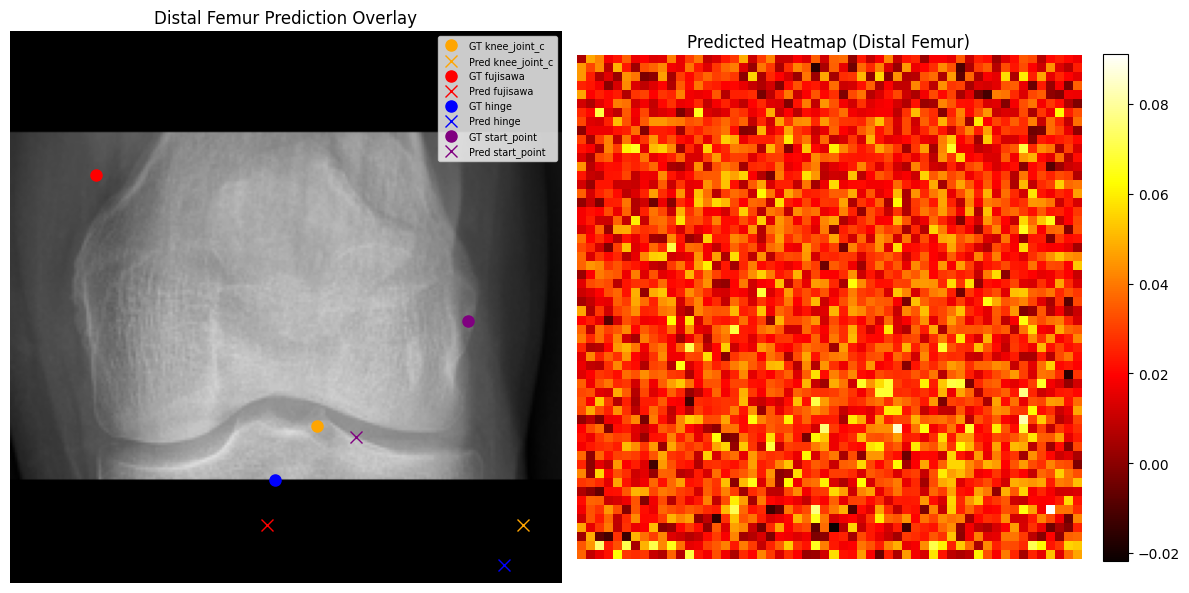

In [18]:
if 'test_loader_df' in locals():
    model_df.eval()
    all_preds, all_gts, sample_batch = [], [], None
    
    with torch.no_grad():
        for batch in test_loader_df:
            imgs, kps = batch["image"].to(device), batch["keypoint"]
            pred_hms = model_df(imgs)
            coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            all_preds.append(coords), all_gts.append(kps)
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), kps, coords)
                
    nmse_val = (torch.mean(torch.sum((torch.cat(all_preds) - torch.cat(all_gts))**2, dim=-1)) / (TARGET_SIZE**2)).item()
    print(f"Distal Femur Test Set NMSE: {nmse_val:.6f}")
    
    visualize_keypoint_evaluation(sample_batch, "Distal Femur", ["knee_joint_c", "fujisawa", "hinge", "start_point"])
else:
    print("Skipping Distal Femur evaluation.")

## Part 5: Ankle Keypoint Detection

In this stage, we crop the detected ankle region using letterbox resizing (to preserve original anatomical aspect ratios) and train a Conformer-based keypoint detector to locate the ankle center (`ankle_c`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset that reads the train/val/test sets generated during Stage 1 to guarantee data consistency, crops the ankle bounding box, applies letterbox padding, and builds 2D Gaussian heatmaps for the keypoint (`ankle_c`) learning objective.

In [19]:
# Ankle Landmarks: ankle center
ankle_kp_names = ["ankle_c"]

if os.path.exists(COCO_JSON_PATH):
    # Initialize Generic Dataset using global configs
    train_ds_ankle = RadiographKeypointDataset(os.path.join(OUTPUT_DIR, "train.txt"), COCO_JSON_PATH, "ankle", ankle_kp_names)
    val_ds_ankle = RadiographKeypointDataset(os.path.join(OUTPUT_DIR, "val.txt"), COCO_JSON_PATH, "ankle", ankle_kp_names)
    test_ds_ankle = RadiographKeypointDataset(os.path.join(OUTPUT_DIR, "test.txt"), COCO_JSON_PATH, "ankle", ankle_kp_names)

    if len(train_ds_ankle) > 0: train_loader_ankle = DataLoader(train_ds_ankle, batch_size=KP_BATCH_SIZE, shuffle=True)
    if len(val_ds_ankle) > 0: val_loader_ankle = DataLoader(val_ds_ankle, batch_size=KP_BATCH_SIZE, shuffle=False)
    if len(test_ds_ankle) > 0: test_loader_ankle = DataLoader(test_ds_ankle, batch_size=KP_BATCH_SIZE, shuffle=False)
    
    print(f"Ankle Stage Loaded! Samples: {len(train_ds_ankle)} train, {len(val_ds_ankle)} val, {len(test_ds_ankle)} test")
else:
    print("Annotations not found; skipping Ankle setup.")

Ankle Stage Loaded! Samples: 54 train, 7 val, 7 test


### Model Initialization & Hyperparameters

Instantiate the Conformer architecture wrapper expecting a single keypoint target (`ankle_c`).

### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps.

Epoch 1/10 (Ankle) | Loss: 0.063471 | Val Loss: 0.004346 | NMSE: 0.293114
Epoch 2/10 (Ankle) | Loss: 0.021937 | Val Loss: 0.004567 | NMSE: 0.235152
Epoch 3/10 (Ankle) | Loss: 0.010845 | Val Loss: 0.005160 | NMSE: 0.257621
Epoch 4/10 (Ankle) | Loss: 0.007457 | Val Loss: 0.005384 | NMSE: 0.305842
Epoch 5/10 (Ankle) | Loss: 0.006052 | Val Loss: 0.005281 | NMSE: 0.269637
Epoch 6/10 (Ankle) | Loss: 0.005473 | Val Loss: 0.005163 | NMSE: 0.157292
Epoch 7/10 (Ankle) | Loss: 0.005093 | Val Loss: 0.005044 | NMSE: 0.289476
Epoch 8/10 (Ankle) | Loss: 0.004896 | Val Loss: 0.004803 | NMSE: 0.319578
Epoch 9/10 (Ankle) | Loss: 0.004765 | Val Loss: 0.004708 | NMSE: 0.189252
Epoch 10/10 (Ankle) | Loss: 0.004635 | Val Loss: 0.004676 | NMSE: 0.261213


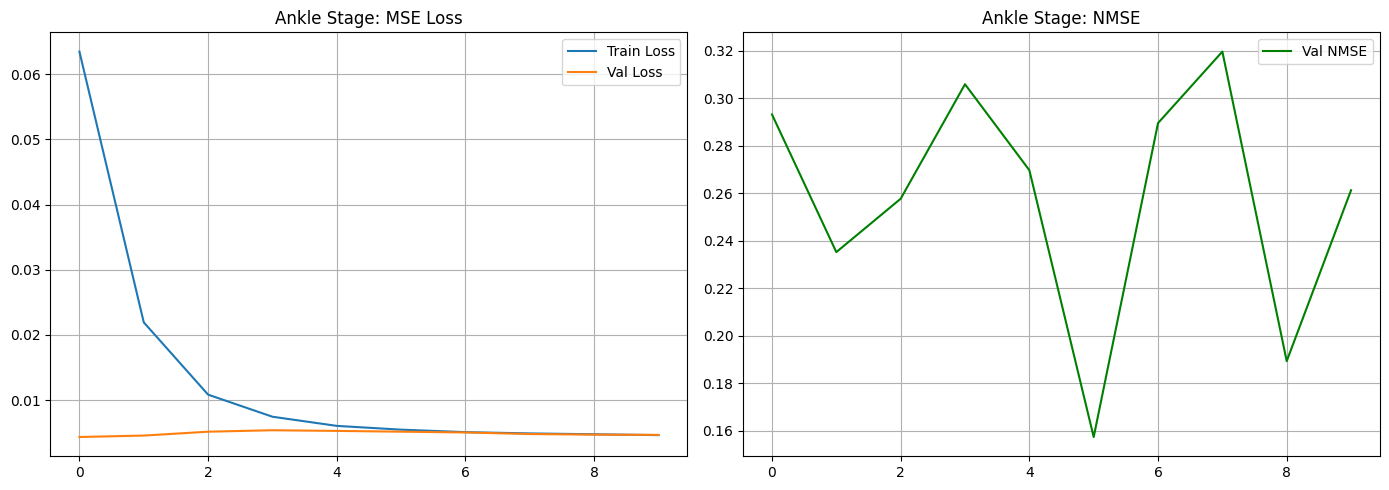

In [20]:
# Instantiate Conformer for Ankle
model_ankle = Conformer_tiny_patch16_keypoint(num_keypoints=1).to(device)
optimizer_ankle = optim.AdamW(model_ankle.parameters(), lr=KP_LEARNING_RATE)

if 'train_loader_ankle' in locals():
    train_losses, val_losses, val_nmses = train_keypoint_model(
        model_ankle, train_loader_ankle, val_loader_ankle, 
        optimizer_ankle, criterion, KP_EPOCHS, device, stage_name="Ankle"
    )
    
    # Plot Metrics
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss"), ax1.plot(val_losses, label="Val Loss")
    ax1.set_title("Ankle Stage: MSE Loss"), ax1.legend(), ax1.grid(True)
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2.set_title("Ankle Stage: NMSE"), ax2.legend(), ax2.grid(True)
    plt.tight_layout(), plt.show()
else:
    print("Skipping Ankle training (Dataset missing).")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps using the supplied `extract_coordinates` utility, compute Normalized MSE, and visualize the ground truth against predictions for the ankle center.

Ankle Test Set NMSE: 0.346501


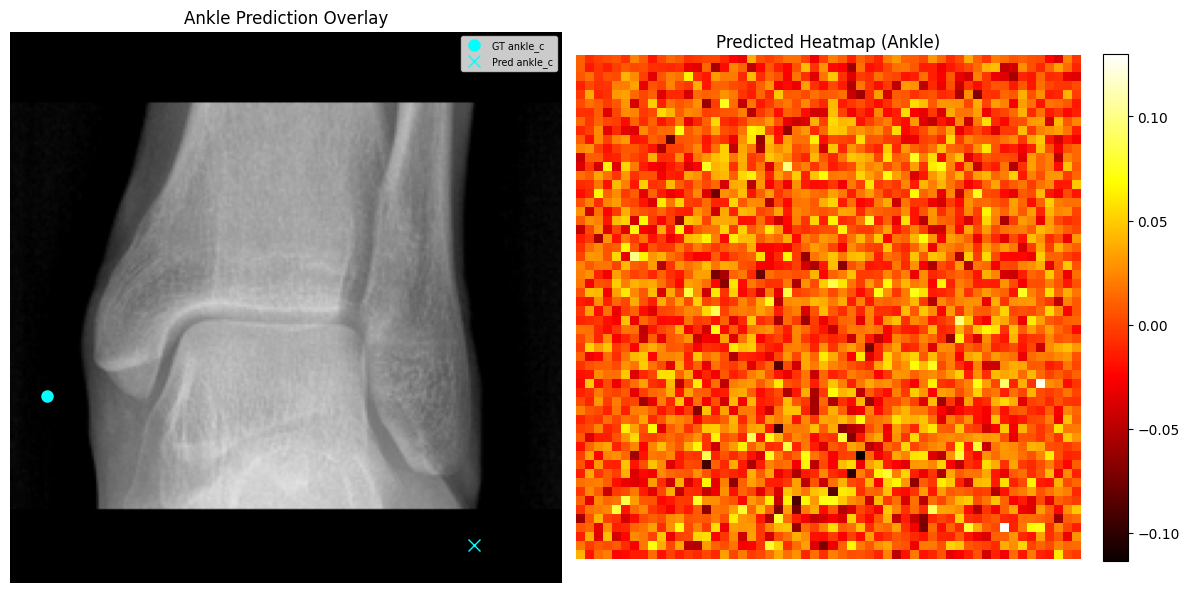

In [21]:
if 'test_loader_ankle' in locals():
    model_ankle.eval()
    all_preds, all_gts, sample_batch = [], [], None
    
    with torch.no_grad():
        for batch in test_loader_ankle:
            imgs, kps = batch["image"].to(device), batch["keypoint"]
            pred_hms = model_ankle(imgs)
            coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            all_preds.append(coords), all_gts.append(kps)
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), kps, coords)
                
    nmse_val = (torch.mean(torch.sum((torch.cat(all_preds) - torch.cat(all_gts))**2, dim=-1)) / (TARGET_SIZE**2)).item()
    print(f"Ankle Test Set NMSE: {nmse_val:.6f}")
    
    visualize_keypoint_evaluation(sample_batch, "Ankle", ["ankle_c"])
else:
    print("Skipping Ankle evaluation.")

## Part 6: Pipeline Evaluation

In this final stage, we integrate the YOLO region detector and the Conformer keypoint detectors into a unified pipeline. For each image in our test set, we calculate the surgical correction angle for a Distal Femoral Osteotomy (DFO) and evaluate the model's accuracy against ground truth annotations.

### Geometry & Mapping Utilities

We define functions to map detected keypoints from localized crops back to the original full-scale radiograph coordinates, as well as geometric functions to compute the mechanical axis, target intersection, and correction angles.

In [22]:
def map_to_orig(kp_final, bbox, target_size=TARGET_SIZE):
    """Maps keypoints from the localized letterboxed crop back to original image coordinates."""
    x_min, y_min, w_orig, h_orig = bbox
    
    scale = min(target_size / w_orig, target_size / h_orig)
    pad_left = (target_size - int(w_orig * scale)) // 2
    pad_top = (target_size - int(h_orig * scale)) // 2
    
    kp_rel_x = (kp_final[0] - pad_left) / scale
    kp_rel_y = (kp_final[1] - pad_top) / scale
    
    return np.array([kp_rel_x + x_min, kp_rel_y + y_min])

def calculate_intersection(p1, p2, target_y):
    """Finds the intersection of the line (p1, p2) with the horizontal line y = target_y."""
    # Line equation: (y - y1) = m(x - x1) where m = (y2-y1)/(x2-x1)
    # x = (y - y1)/m + x1
    if p2[0] == p1[0]: # Vertical line
        return p1[0]
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    if m == 0: return p1[0] # Avoiding division by zero for horizontal axis
    x_at_y = (target_y - p1[1]) / m + p1[0]
    return x_at_y

def calculate_angle(vertex, p1, p2):
    """Calculates the angle (in degrees) between vectors vertex->p1 and vertex->p2."""
    v1 = p1 - vertex
    v2 = p2 - vertex
    
    unit_v1 = v1 / np.linalg.norm(v1)
    unit_v2 = v2 / np.linalg.norm(v2)
    
    dot_product = np.dot(unit_v1, unit_v2)
    angle = np.arccos(np.clip(dot_product, -1.0, 1.0))
    return np.degrees(angle)

def get_dfo_angle(points):
    """
    Computes correction angle Alpha given points in original space.
    points dict: {fem_head_c, knee_joint_c, fujisawa, hinge, start_point, ankle_c}
    """
    # 1. Current Mechanical Axis: fem_head_c to ankle_c
    # 2. New Target Axis: fem_head_c through Fujisawa point
    ankle_y = points["ankle_c"][1]
    
    # Intersection of Target Axis with ankle level
    target_intersect_x = calculate_intersection(points["fem_head_c"], points["fujisawa"], ankle_y)
    target_point_at_ankle = np.array([target_intersect_x, ankle_y])
    
    # 3. Correction Angle (Alpha) at Hinge
    alpha = calculate_angle(points["hinge"], points["ankle_c"], target_point_at_ankle)
    return alpha, target_point_at_ankle

### End-to-End Inference Pipeline

We iterate through the test images, perform detection, local keypoint refinement, and compute the resulting DFO correction angles. This is compared against the ground truth derived from COCO annotations.

In [23]:
# Load COCO annotations for ground truth comparison
with open(COCO_JSON_PATH, "r") as f:
    coco_eval_data = json.load(f)

img_info_eval = {img["file_name"]: img for img in coco_eval_data["images"]}
ann_by_img_eval = {}
for ann in coco_eval_data["annotations"]:
    img_id = ann["image_id"]
    if img_id not in ann_by_img_eval:
        ann_by_img_eval[img_id] = []
    ann_by_img_eval[img_id].append(ann)

def run_test_pipeline(test_img_paths):
    pipeline_results = []
    
    # Set models to eval mode
    model.eval()
    
    # Use globals() to check for model availability from within function scope
    h_m = globals().get('model_hip')
    d_m = globals().get('model_df')
    a_m = globals().get('model_ankle')
    
    if h_m: h_m.eval()
    if d_m: d_m.eval()
    if a_m: a_m.eval()
    
    required = ["fem_head_c", "fujisawa", "hinge", "ankle_c"]
    print(f"Starting pipeline evaluation on {len(test_img_paths)} images...")
    
    for img_idx, img_path in enumerate(test_img_paths):
        filename = os.path.basename(img_path)
        if filename not in img_info_eval:
            print(f"[{img_idx+1}] {filename}: Not found in COCO metadata. Skipping.")
            continue
        
        img_orig = Image.open(img_path).convert("RGB")
        
        # 1. YOLO Region Detection
        yolo_res = model(img_path, verbose=False)[0]
        boxes = yolo_res.boxes.xyxy.cpu().numpy()
        classes = yolo_res.boxes.cls.cpu().numpy()
        
        pred_pts_orig = {}
        
        # 2. Keypoint Detection per ROI
        for i in range(len(classes)):
            cls_name = CLASSES[int(classes[i])]
            box = boxes[i] # [x1, y1, x2, y2]
            bbox_wh = [box[0], box[1], box[2]-box[0], box[3]-box[1]]
            
            # ROI Preprocessing
            roi_img, scale, padding = preprocess_roi(img_orig, bbox_wh, TARGET_SIZE)
            roi_tensor = torch.from_numpy(np.array(roi_img)).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
            
            with torch.no_grad():
                if cls_name == "hip" and h_m:
                    pred_hm = h_m(roi_tensor)
                    coords = extract_coordinates(pred_hm.cpu(), scale_factor=4.0).squeeze().numpy()
                    pred_pts_orig["fem_head_c"] = map_to_orig(coords, bbox_wh)
                    
                elif cls_name == "distal_femur" and d_m:
                    pred_hm = d_m(roi_tensor)
                    coords = extract_coordinates(pred_hm.cpu(), scale_factor=4.0).squeeze().numpy() # [4, 2]
                    for k_idx, k_name in enumerate(["knee_joint_c", "fujisawa", "hinge", "start_point"]):
                        pred_pts_orig[k_name] = map_to_orig(coords[k_idx], bbox_wh)
                        
                elif cls_name == "ankle" and a_m:
                    pred_hm = a_m(roi_tensor)
                    coords = extract_coordinates(pred_hm.cpu(), scale_factor=4.0).squeeze().numpy()
                    pred_pts_orig["ankle_c"] = map_to_orig(coords, bbox_wh)
        
        # Ground Truth from COCO
        gt_pts_orig = {}
        img_id = img_info_eval[filename]["id"]
        annotations = ann_by_img_eval.get(img_id, [])
        
        for ann in annotations:
            cat_name = CLASSES[ann["category_id"]-1]
            if not ann.get("keypoints"): continue
            
            kps = ann["keypoints"]
            if cat_name == "hip":
                gt_pts_orig["fem_head_c"] = np.array([kps[0], kps[1]])
            elif cat_name == "distal_femur":
                for k_idx, k_name in enumerate(["knee_joint_c", "fujisawa", "hinge", "start_point"]):
                    gt_pts_orig[k_name] = np.array([kps[k_idx*3], kps[k_idx*3+1]])
            elif cat_name == "ankle":
                gt_pts_orig["ankle_c"] = np.array([kps[0], kps[1]])
        
        # Reporting
        pred_missing = [k for k in required if k not in pred_pts_orig]
        gt_missing = [k for k in required if k not in gt_pts_orig]
        
        if pred_missing or gt_missing:
            msg = f"[{img_idx+1}] {filename}: Incomplete. "
            if gt_missing: msg += f"GT missing: {gt_missing}. "
            if pred_missing: msg += f"Pred missing: {pred_missing}. "
            print(msg)
            continue
            
        pred_angle, pred_target_ankle = get_dfo_angle(pred_pts_orig)
        pred_pts_orig["target_at_ankle"] = pred_target_ankle
        
        gt_angle, gt_target_ankle = get_dfo_angle(gt_pts_orig)
        gt_pts_orig["target_at_ankle"] = gt_target_ankle
        
        pipeline_results.append({
            "filename": filename,
            "pred_angle": pred_angle,
            "gt_angle": gt_angle,
            "pred_pts": pred_pts_orig,
            "gt_pts": gt_pts_orig,
            "img_path": img_path
        })
        print(f"[{img_idx+1}] {filename}: Success. GT Alpha: {gt_angle:.2f}, Pred Alpha: {pred_angle:.2f}")
                
    return pipeline_results

if os.path.exists(os.path.join(OUTPUT_DIR, "test.txt")):
    with open(os.path.join(OUTPUT_DIR, "test.txt"), "r") as f:
        test_img_filenames = f.read().splitlines()
    eval_results = run_test_pipeline(test_img_filenames[:20])
    
    if eval_results:
        errors = [(r["pred_angle"] - r["gt_angle"])**2 for r in eval_results]
        print(f"\nEvaluation Complete. MSE for Alpha: {np.mean(errors):.4f}")
    else:
        print("\nERROR: No complete cases found. Check the logs above.")
else:
    print("Test split file not found; skipping pipeline evaluation.")

Starting pipeline evaluation on 7 images...
[1] 23_0.png: Success. GT Alpha: 12.23, Pred Alpha: 6.54
[2] 27_0.png: Incomplete. Pred missing: ['ankle_c']. 
[3] 38_0.png: Success. GT Alpha: 7.09, Pred Alpha: 4.13
[4] 41_0.png: Incomplete. Pred missing: ['fujisawa', 'hinge']. 
[5] 45_0.png: Incomplete. Pred missing: ['fujisawa', 'hinge']. 
[6] 13_0.png: Success. GT Alpha: 4.09, Pred Alpha: 1.45
[7] 24_0.png: Incomplete. Pred missing: ['fem_head_c']. 

Evaluation Complete. MSE for Alpha: 16.0376


### Visualization of Pipeline Results

We visualize the ground truth versus predicted keypoints and surgical planning axes. The mechanical axis (original) and target axis (new) are overlaid on the radiographs.

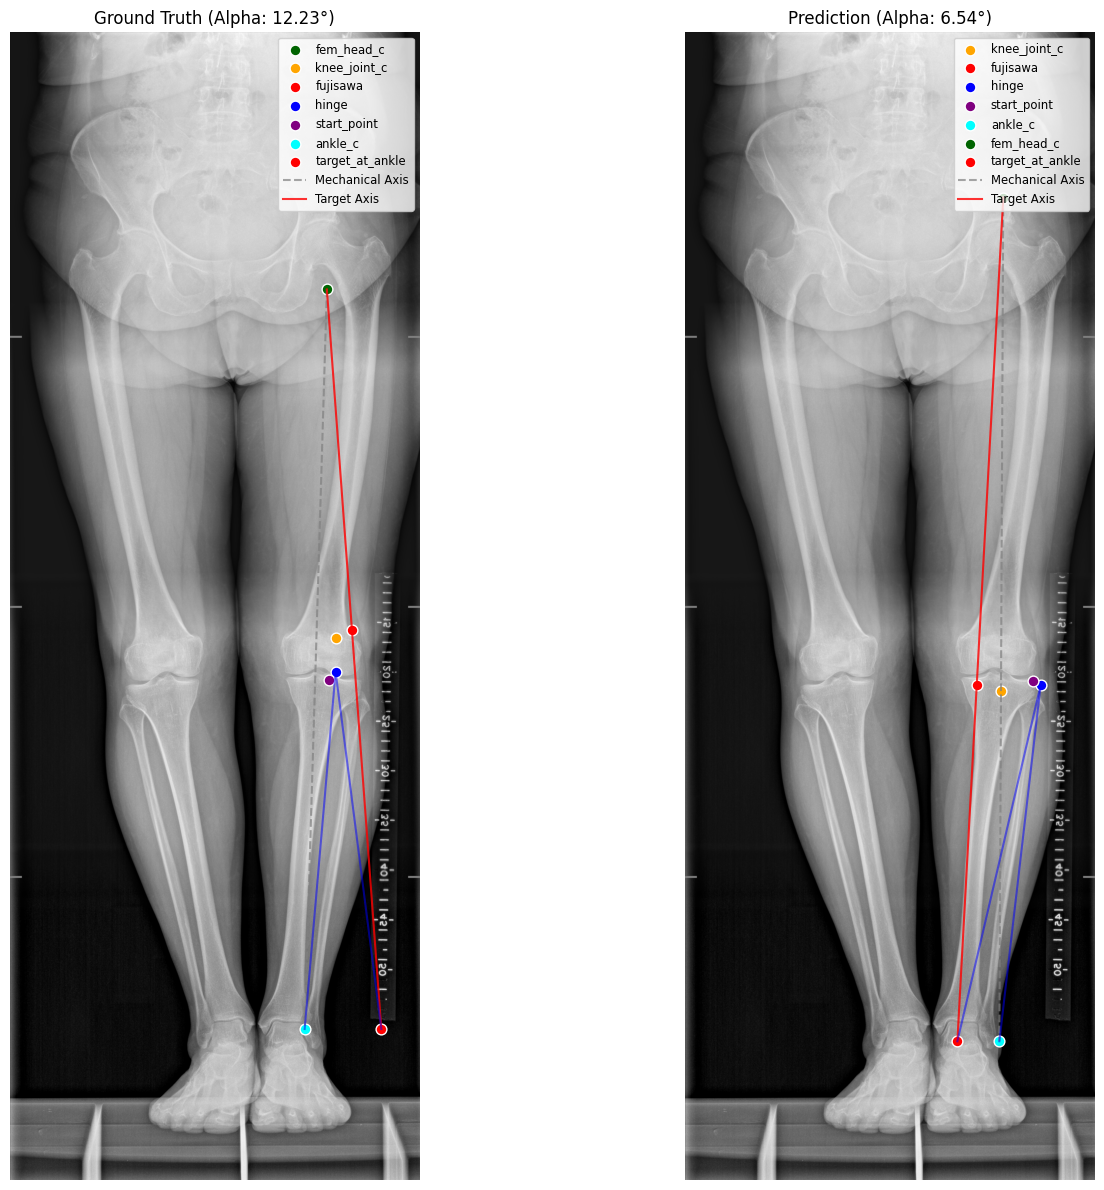

File: 23_0.png
Ground Truth Correction Angle: 12.2347°
Predicted Correction Angle:    6.5450°
Difference:                     5.6897°


In [24]:
if eval_results:
    sample = random.choice(eval_results)
    img_path = sample["img_path"]
    img = Image.open(img_path).convert("RGB")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12))
    
    def plot_analysis(ax, pts, angle, title):
        ax.imshow(img, cmap="gray")
        ax.set_title(title)
        
        # Plot points with mapping colors
        for name, p in pts.items():
            if name in LANDMARK_COLORS:
                c = LANDMARK_COLORS[name]
                ax.scatter(p[0], p[1], s=60, color=c, label=name, edgecolors='white', linewidths=1)
        
        # Draw Lines
        # Mechanical Axis: Fem Head to Ankle Center
        ax.plot([pts["fem_head_c"][0], pts["ankle_c"][0]], 
                [pts["fem_head_c"][1], pts["ankle_c"][1]], color='gray', linestyle='--', alpha=0.7, label="Mechanical Axis")
        
        # Target Axis: Fem Head to Target at Ankle
        ax.plot([pts["fem_head_c"][0], pts["target_at_ankle"][0]], 
                [pts["fem_head_c"][1], pts["target_at_ankle"][1]], color='red', linestyle='-', alpha=0.8, label="Target Axis")
        
        # Hinge to Ankle and Hinge to Target at Ankle (Correction Arc)
        ax.plot([pts["hinge"][0], pts["ankle_c"][0]], 
                [pts["hinge"][1], pts["ankle_c"][1]], color='blue', linestyle='-', alpha=0.5)
        ax.plot([pts["hinge"][0], pts["target_at_ankle"][0]], 
                [pts["hinge"][1], pts["target_at_ankle"][1]], color='blue', linestyle='-', alpha=0.5)
        
        ax.axis("off")
        ax.legend(loc='upper right', fontsize='small')

    plot_analysis(ax1, sample["gt_pts"], sample["gt_angle"], f"Ground Truth (Alpha: {sample['gt_angle']:.2f}°)")
    plot_analysis(ax2, sample["pred_pts"], sample["pred_angle"], f"Prediction (Alpha: {sample['pred_angle']:.2f}°)")
    
    plt.tight_layout()
    plt.show()
    
    print(f"File: {sample['filename']}")
    print(f"Ground Truth Correction Angle: {sample['gt_angle']:.4f}°")
    print(f"Predicted Correction Angle:    {sample['pred_angle']:.4f}°")
    print(f"Difference:                     {abs(sample['pred_angle'] - sample['gt_angle']):.4f}°")
else:
    print("No evaluation results to visualize.")